In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# tensorflow version
import tensorflow
print('tensorflow: %s' % tensorflow.__version__)
# keras version
import keras
print('keras: %s' % keras.__version__)

tensorflow: 2.19.0
keras: 3.10.0


## Schematic Model :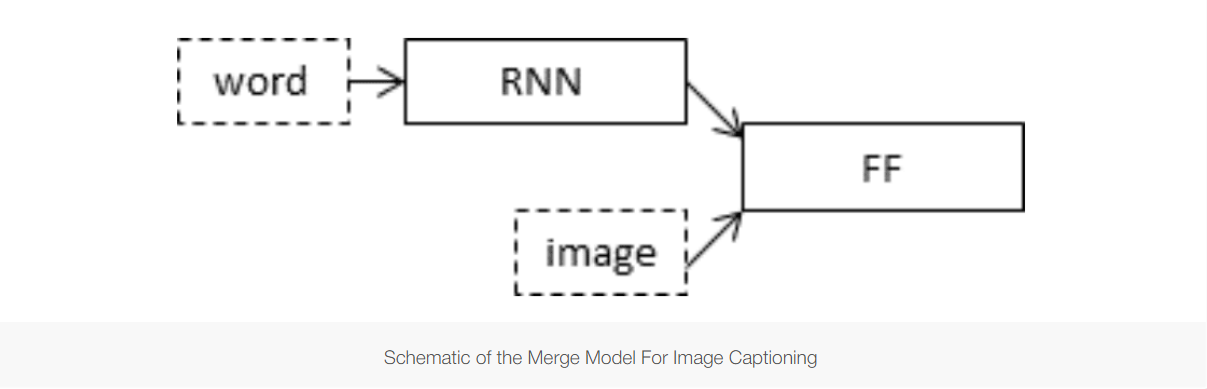

# 🖼️ VGG16 Feature Extraction Process (Transfer Learning)

The goal of this phase is to pre-process raw images into a powerful, numerical representation (features) once, to dramatically speed up the training of the subsequent language model.

## Key Concept: Why Pre-Compute Features?

* **Optimization:** Running a large model like VGG16 repeatedly for every training epoch is slow and redundant.
* **Efficiency:** By extracting and saving the features beforehand, training the language model (LSTM Decoder) becomes much faster and consumes significantly less memory.

---

##  Feature Extraction Process

### 1. Model Selection and Loading
* **Select Pre-Trained Model:** The **VGG16** Convolutional Neural Network (CNN)—a model pre-trained on the ImageNet dataset—is chosen as the image interpreter (Encoder).
* **Load and Truncate VGG16:** The VGG16 model is loaded via Keras. The **final classification layer** is **removed** (truncated).

### 2. Feature Definition
* **Define Output:** The output is set to be the vector from the layer *before* the final classification (the second-to-last layer, often called `fc2`). This vector represents the high-level **image features** or numerical summary.

### 3. Image Processing and Prediction
* **Image Preparation:** Each photo must be loaded and resized to the size preferred by VGG16 (e.g., a $224 \times 224$ pixel, 3-channel array).
* **Feature Prediction:** The prepared image is passed through the truncated VGG16 model.
* **Output Vector:** The result is a **1-dimensional vector with 4,096 elements**. This is the final **image feature vector**.

### 4. Storage and Downstream Use
* **Saving:** The feature vector for each image is computed and saved to a file (e.g., a dictionary saved via Pickle). **This process only happens once.**
* **Downstream Use:** In the subsequent training of the caption generation model (LSTM Decoder), the image features are loaded directly from the saved file, bypassing the need to run the slow VGG16 process repeatedly.

In [ ]:
from os import listdir
from pickle import dump
from keras.applications.vgg16 import VGG16
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.applications.vgg16 import preprocess_input
from keras.models import Model

def extract_features(directory):
    model = VGG16()
    model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
    print(model.summary())
    features = dict()

    for name in listdir(directory):
        filename = directory + '/' + name
        image = load_img(filename, target_size=(224, 224))
        image = img_to_array(image)
        image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
        image = preprocess_input(image)
        feature = model.predict(image, verbose=0)
        image_id = name.split('.')[0]
        features[image_id] = feature
        print('>%s' % name)

    return features





---

###  Text Cleaning

Each caption is preprocessed to reduce noise and standardize the text:

- Convert all words to **lowercase**
- Remove **punctuation**
- Remove **single-character tokens**
- Remove **numeric tokens**
- Retain only **alphabetic words**

This cleaning process improves vocabulary consistency and model learning.

---

### 🔹 Step 3: Adding Sequence Tokens

Two special tokens are added to every caption:

- `startseq` → indicates the beginning of a caption  
- `endseq` → indicates the end of a caption  

SAVE CAPTIONS


In [ ]:
import string

# load doc into memory
def load_doc(filename):
	# open the file as read only
	file = open(filename, 'r')
	# read all text
	text = file.read()
	# close the file
	file.close()
	return text

# extract descriptions for images
def load_descriptions(doc):
	mapping = dict()
	# process lines
	for line in doc.split('\n'):
		# split line by white space
		tokens = line.split()
		if len(line) < 2:
			continue
		# take the first token as the image id, the rest as the description
		image_id, image_desc = tokens[0], tokens[1:]
		# remove filename from image id
		image_id = image_id.split('.')[0]
		# convert description tokens back to string
		image_desc = ' '.join(image_desc)
		# create the list if needed
		if image_id not in mapping:
			mapping[image_id] = list()
		# store description
		mapping[image_id].append(image_desc)
	return mapping

def clean_descriptions(descriptions):
	# prepare translation table for removing punctuation
	table = str.maketrans('', '', string.punctuation)
	for key, desc_list in descriptions.items():
		for i in range(len(desc_list)):
			desc = desc_list[i]
			# tokenize
			desc = desc.split()
			# convert to lower case
			desc = [word.lower() for word in desc]
			# remove punctuation from each token
			desc = [w.translate(table) for w in desc]
			# remove hanging 's' and 'a'
			desc = [word for word in desc if len(word)>1]
			# remove tokens with numbers in them
			desc = [word for word in desc if word.isalpha()]
			# store as string
			desc_list[i] =  ' '.join(desc)

# convert the loaded descriptions into a vocabulary of words
def to_vocabulary(descriptions):
	# build a list of all description strings
	all_desc = set()
	for key in descriptions.keys():
		[all_desc.update(d.split()) for d in descriptions[key]]
	return all_desc

# save descriptions to file, one per line
def save_descriptions(descriptions, filename):
	lines = list()
	for key, desc_list in descriptions.items():
		for desc in desc_list:
			lines.append(key + ' ' + desc)
	data = '\n'.join(lines)
	file = open(filename, 'w')
	file.write(data)
	file.close()

filename = '/content/drive/MyDrive/Flickr8/Flickr8k_text/Flickr8k.token.txt'
# load descriptions
doc = load_doc(filename)
# parse descriptions
descriptions = load_descriptions(doc)
print('Loaded: %d ' % len(descriptions))
# clean descriptions
clean_descriptions(descriptions)
# summarize vocabulary
vocabulary = to_vocabulary(descriptions)
print('Vocabulary Size: %d' % len(vocabulary))
# save to file
save_descriptions(descriptions, '/content/drive/MyDrive/Flickr8/descriptions.txt')

In [4]:
from pickle import load

# load doc into memory
def load_doc(filename):
	# open the file as read only
	file = open(filename, 'r')
	# read all text
	text = file.read()
	# close the file
	file.close()
	return text


# load a pre-defined list of photo identifiers
def load_set(filename):
    doc = load_doc(filename)
    dataset = list()
    for line in doc.split('\n'):
        # skip empty lines
        if len(line.strip()) == 0:
            continue
        # skip header line
        if line.lower().startswith("image,caption"):
            continue
        # get the image identifier
        identifier = line.split('.')[0]
        dataset.append(identifier)
    return set(dataset)

# load clean descriptions into memory
def load_clean_descriptions(filename, dataset):
	# load document
	doc = load_doc(filename)
	descriptions = dict()
	for line in doc.split('\n'):
		# split line by white space
		tokens = line.split()
		# split id from description
		image_id, image_desc = tokens[0], tokens[1:]
		# skip images not in the set
		if image_id in dataset:
			# create list
			if image_id not in descriptions:
				descriptions[image_id] = list()
			# wrap description in tokens
			desc = 'startseq ' + ' '.join(image_desc) + ' endseq'
			# store
			descriptions[image_id].append(desc)
	return descriptions

# load photo features
def load_photo_features(filename, dataset):
	# load all features
	all_features = load(open(filename, 'rb'))
	# filter features
	features = {k: all_features[k] for k in dataset}
	return features

# load training dataset (6K)
filename = '/content/drive/MyDrive/Flickr8/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))
# descriptions
train_descriptions = load_clean_descriptions('/content/drive/MyDrive/Flickr8/descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))
# photo features
train_features = load_photo_features('/content/drive/MyDrive/Flickr8/features.pkl', train)
print('Photos: train=%d' % len(train_features))

Dataset: 6000
Descriptions: train=6000
Photos: train=6000


In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer

# convert a dictionary of clean descriptions to a list of descriptions
def to_lines(descriptions):
	all_desc = list()
	for key in descriptions.keys():
		[all_desc.append(d) for d in descriptions[key]]
	return all_desc

# fit a tokenizer given caption descriptions
def create_tokenizer(descriptions):
	lines = to_lines(descriptions)
	tokenizer = Tokenizer()
	tokenizer.fit_on_texts(lines)
	return tokenizer

# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size: %d' % vocab_size)

Vocabulary Size: 7579


In [6]:
# create sequences of images, input sequences and output words for an image
def create_sequences(tokenizer, max_length, descriptions, photos, vocab_size):
	X1, X2, y = list(), list(), list()
	# walk through each image identifier
	for key, desc_list in descriptions.items():
		# walk through each description for the image
		for desc in desc_list:
			# encode the sequence
			seq = tokenizer.texts_to_sequences([desc])[0]
			# split one sequence into multiple X,y pairs
			for i in range(1, len(seq)):
				# split into input and output pair
				in_seq, out_seq = seq[:i], seq[i]
				# pad input sequence
				in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
				# encode output sequence
				out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
				# store
				X1.append(photos[key][0])
				X2.append(in_seq)
				y.append(out_seq)
	return array(X1), array(X2), array(y)

In [7]:
# calculate the length of the description with the most words
def max_length(descriptions):
	lines = to_lines(descriptions)
	return max(len(d.split()) for d in lines)

## 🧠 Model Training, Evaluation & Caption Prediction

After completing **image feature extraction** and **text preparation**, the next stages involve training the image captioning model, evaluating its performance, and finally generating captions for new images.

---

## 🏗️ Model Architecture (Encoder–Decoder)

This project uses an **Encoder–Decoder architecture**:

### 🔹 Encoder (Image Features)
- Pre-extracted **VGG16 features (4096-dim)** act as the image representation.
- Features are passed through:
  - `Dropout(0.5)`
  - `Dense(256, ReLU)`

### 🔹 Decoder (Language Model)
- Captions are processed using:
  - `Embedding(vocab_size, 256, mask_zero=True)`
  - `LSTM(256)`
- The image embedding and text embedding are **merged using element-wise addition**.
- Final layers:
  - `Dense(256, ReLU)`
  - `Dense(vocab_size, Softmax)` → predicts next word

This setup allows the model to **condition word generation on both image content and previous words**.

---

## 🔁 Sequence Generation Logic

For each caption:
- The caption is converted into **multiple input-output pairs**  
- Example:



In [8]:
from keras.models import Model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from keras.utils import plot_model
from keras.callbacks import ModelCheckpoint


In [10]:
max_length_value = max_length(train_descriptions)
print("max caption length is :",max_length_value)

max caption length is : 34


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 30, 256)   │  1,940,224 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 4096)      │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 30, 256)   │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 30)        │          0 │ input_layer_6[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │  1,048,832 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 256)       │    525,312 │ dropout_6[0][0],  │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256)       │          0 │ dense_7[0][0],    │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │     65,792 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 7579)      │  1,947,803 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,527,963 (21.09 MB)

 Trainable params: 5,527,963 (21.09 MB)

 Non-trainable params: 0 (0.00 B)

None


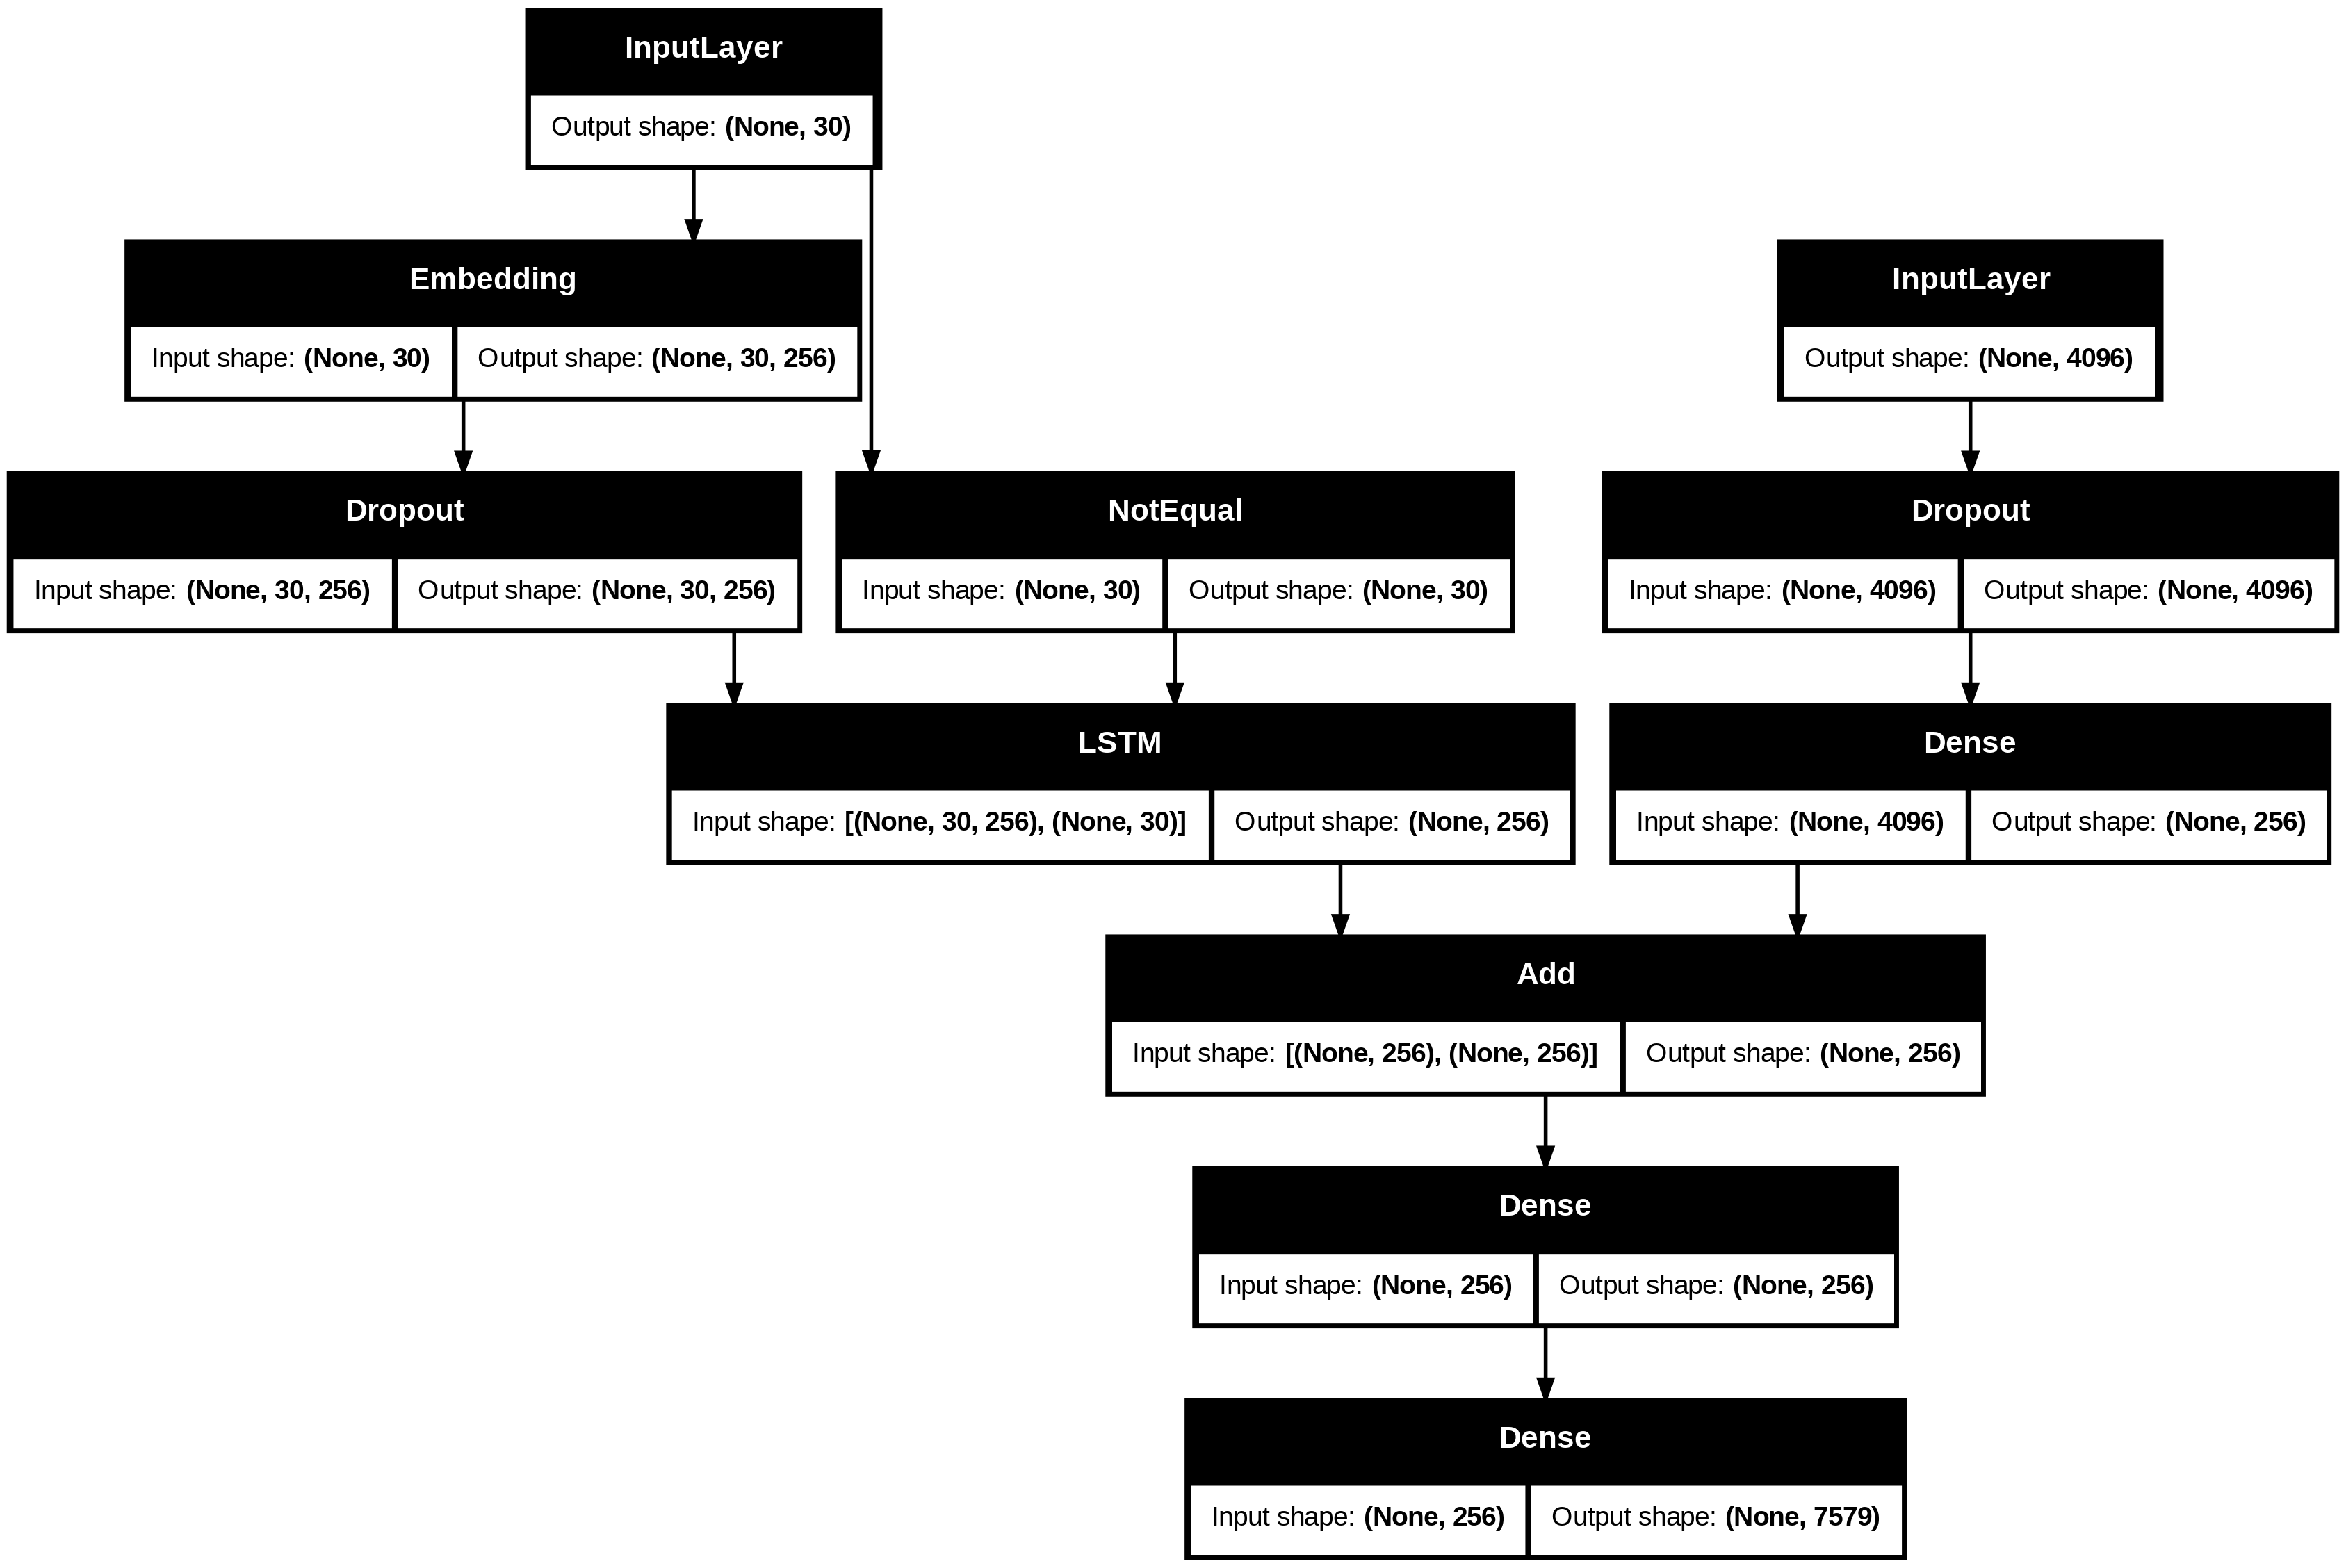

In [25]:
# define the captioning model
# feature extractor model
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)
# sequence model
inputs2 = Input(shape=(max_length_value,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256, use_cudnn=False)(se2) # Added use_cudnn=False
# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)
# tie it together [image, seq] [word]
model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')
# summarize model
print(model.summary())
plot_model(model, to_file='/content/drive/MyDrive/Flickr8/model.png', show_shapes=True)


## ⚙️ Training Strategy

### 🔹 Data Generator
To efficiently handle large datasets:
- A **custom generator** creates batches on the fly
- Prevents loading all sequences into memory
- Outputs:
  - Image features `(4096)`
  - Caption sequence `(max_length)`
  - One-hot encoded next word `(vocab_size)`

### 🔹 Training Details
- Loss Function: `categorical_crossentropy`
- Optimizer: `Adam`
- Batch Size: `256 / 512`
- Epochs: `20`
- Framework: `tf.data.Dataset` for performance

### 🔹 Model Saving
After training, the model is saved 


In [26]:
from numpy import array
from pickle import load

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.callbacks import ModelCheckpoint


In [27]:
# ---------- FIXED MAX LENGTH FUNCTION ----------
def get_max_length(descriptions):
    return max(len(d.split()) for desc_list in descriptions.values() for d in desc_list)



# ---------- TRAIN DATA ----------
filename = '/content/drive/MyDrive/Flickr8/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))

train_descriptions = load_clean_descriptions('/content/drive/MyDrive/Flickr8/descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))

train_features = load_photo_features('/content/drive/MyDrive/Flickr8/features.pkl', train)
print('Photos: train=%d' % len(train_features))

tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size:', vocab_size)

max_length_value = min(get_max_length(train_descriptions), 30)
print('Max Caption Length:', max_length_value)








Dataset: 6000
Descriptions: train=6000
Photos: train=6000
Vocabulary Size: 7579
Max Caption Length: 30


In [28]:
def data_generator(descriptions, photos, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = [], [], []

    while True:
        for key, desc_list in descriptions.items():
            photo = photos[key][0]

            for desc in desc_list:
                seq = tokenizer.texts_to_sequences([desc])[0]

                for i in range(1, len(seq)):
                    in_seq = seq[:i]
                    out_seq = seq[i]

                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(photo)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield (
                            np.array(X1, dtype="float32"),
                            np.array(X2, dtype="int32")
                        ), np.array(y, dtype="float32")

                        X1, X2, y = [], [], []


In [29]:
import tensorflow as tf

dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(
        train_descriptions,
        train_features,
        tokenizer,
        max_length_value,
        vocab_size,
        batch_size=512
    ),
    output_signature=(
        (
            tf.TensorSpec(shape=(None, 4096), dtype=tf.float32),
            tf.TensorSpec(shape=(None, max_length_value), dtype=tf.int32),
        ),
        tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
    )
)


In [30]:
batch_size = 256

In [31]:
total_sequences = sum(len(d.split()) - 1 for v in train_descriptions.values() for d in v)
steps = total_sequences // batch_size


In [32]:
import numpy as np


In [33]:
model.fit(
    dataset,
    steps_per_epoch=steps,
    epochs=20,
    verbose=1
)


Epoch 1/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 58s 43ms/step - loss: 4.9998
Epoch 2/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - loss: 3.4493
Epoch 3/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - loss: 3.0179
Epoch 4/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - loss: 2.7520
Epoch 5/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - loss: 2.5734
Epoch 6/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - loss: 2.4475
Epoch 7/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - loss: 2.3485
Epoch 8/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - loss: 2.2692
Epoch 9/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - loss: 2.2023
Epoch 10/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - loss: 2.1463
Epoch 11/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - loss: 2.0999
Epoch 12/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - loss: 2.0565
Epoch 13/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - loss: 2.0179
Epoch 14/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - loss: 1.9827
E

In [34]:
model.save('/content/drive/MyDrive/Flickr8/Image_caption_model.h5')
print("Model Saved Successfully")

Model Saved Successfully


In [39]:
model.save('/content/drive/MyDrive/Flickr8/caption_model.keras')
print("Model saved successfully!")


Model saved successfully!



---

## 📊 Model Evaluation (BLEU Score)

To evaluate caption quality, **BLEU scores** are used:

- **BLEU-1** → unigram precision
- **BLEU-2** → bigram precision
- **BLEU-3** → trigram precision
- **BLEU-4** → 4-gram precision

### Evaluation Process:
1. Generate a caption for each test image
2. Compare generated caption with all reference captions
3. Compute BLEU scores using `nltk.corpus_bleu`

Higher BLEU scores indicate better alignment with human-written captions.

---

## 📝 Caption Generation (Inference)

### 🔹 Caption Prediction Steps
1. Load trained model and tokenizer
2. Extract VGG16 features for a **new image**
3. Start with the token `startseq`
4. Predict one word at a time using the model
5. Append predicted word back to input
6. Stop when:
   - `endseq` is predicted  
   - or maximum caption length is reached

### 🔹 Example Output


In [41]:
import numpy as np
from numpy import argmax
from pickle import load
from nltk.translate.bleu_score import corpus_bleu

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [43]:
BASE_PATH = '/content/drive/MyDrive/Flickr8'

# load training image ids
train_ids = load_set(f'{BASE_PATH}/Flickr8k_text/Flickr_8k.trainImages.txt')

# load clean training descriptions
train_descriptions = load_clean_descriptions(
    f'{BASE_PATH}/descriptions.txt',
    train_ids
)

print("Train descriptions loaded:", len(train_descriptions))


# recreate tokenizer EXACTLY as training
def to_lines(descriptions):
    all_desc = []
    for key in descriptions:
        all_desc.extend(descriptions[key])
    return all_desc

tokenizer = Tokenizer()
tokenizer.fit_on_texts(to_lines(train_descriptions))

vocab_size = len(tokenizer.word_index) + 1
print("Tokenizer recreated")
print("Vocabulary size:", vocab_size)


Train descriptions loaded: 6000
Tokenizer recreated
Vocabulary size: 7579


In [44]:
def get_max_length(descriptions):
    return max(len(d.split()) for desc_list in descriptions.values() for d in desc_list)

max_length_value = min(get_max_length(train_descriptions), 30)
print("Max caption length:", max_length_value)


Max caption length: 30


In [45]:
# load test image ids
test_ids = load_set(f'{BASE_PATH}/Flickr8k_text/Flickr_8k.testImages.txt')
print("Test images:", len(test_ids))

# load test descriptions
test_descriptions = load_clean_descriptions(
    f'{BASE_PATH}/descriptions.txt',
    test_ids
)
print("Test descriptions:", len(test_descriptions))

# load test features
test_features = load_photo_features(
    f'{BASE_PATH}/features.pkl',
    test_ids
)
print("Test features:", len(test_features))


Test images: 1000
Test descriptions: 1000
Test features: 1000


In [46]:
model = load_model(f'{BASE_PATH}/caption_model.keras')
print("Model loaded successfully!")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [50]:
def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'startseq'

    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]

        # ✅ IMPORTANT: right padding
        seq = pad_sequences(
            [seq],
            maxlen=max_length,
            padding='post'
        )

        yhat = model.predict([photo, seq], verbose=0)
        yhat = np.argmax(yhat)

        word = tokenizer.index_word.get(yhat)
        if word is None:
            break

        in_text += ' ' + word
        if word == 'endseq':
            break

    return in_text


In [48]:
def evaluate_model(model, descriptions, photos, tokenizer, max_length):
    actual, predicted = [], []

    for key, desc_list in descriptions.items():
        yhat = generate_desc(model, tokenizer, photos[key], max_length)

        references = [d.split() for d in desc_list]
        actual.append(references)
        predicted.append(yhat.split())

    print('BLEU-1:', corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
    print('BLEU-2:', corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))
    print('BLEU-3:', corpus_bleu(actual, predicted, weights=(0.3, 0.3, 0.3, 0)))
    print('BLEU-4:', corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25)))


In [51]:
evaluate_model(
    model,
    test_descriptions,
    test_features,
    tokenizer,
    max_length_value
)


BLEU-1: 0.506895631283922
BLEU-2: 0.28249646739421747
BLEU-3: 0.2014689938841369
BLEU-4: 0.09791949402696415


In [56]:
from tensorflow.keras.preprocessing.text import Tokenizer
from pickle import dump

# load doc into memory
def load_doc(filename):
	# open the file as read only
	file = open(filename, 'r')
	# read all text
	text = file.read()
	# close the file
	file.close()
	return text

# load a pre-defined list of photo identifiers
def load_set(filename):
	doc = load_doc(filename)
	dataset = list()
	# process line by line
	for line in doc.split('\n'):
		# skip empty lines
		if len(line) < 1:
			continue
		# get the image identifier
		identifier = line.split('.')[0]
		dataset.append(identifier)
	return set(dataset)

# load clean descriptions into memory
def load_clean_descriptions(filename, dataset):
	# load document
	doc = load_doc(filename)
	descriptions = dict()
	for line in doc.split('\n'):
		# split line by white space
		tokens = line.split()
		# split id from description
		image_id, image_desc = tokens[0], tokens[1:]
		# skip images not in the set
		if image_id in dataset:
			# create list
			if image_id not in descriptions:
				descriptions[image_id] = list()
			# wrap description in tokens
			desc = 'startseq ' + ' '.join(image_desc) + ' endseq'
			# store
			descriptions[image_id].append(desc)
	return descriptions

# covert a dictionary of clean descriptions to a list of descriptions
def to_lines(descriptions):
	all_desc = list()
	for key in descriptions.keys():
		[all_desc.append(d) for d in descriptions[key]]
	return all_desc

# fit a tokenizer given caption descriptions
def create_tokenizer(descriptions):
	lines = to_lines(descriptions)
	tokenizer = Tokenizer()
	tokenizer.fit_on_texts(lines)
	return tokenizer

# load training dataset (6K)
filename = '/content/drive/MyDrive/Flickr8/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))
# descriptions
train_descriptions = load_clean_descriptions('/content/drive/MyDrive/Flickr8/descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))
# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)
# save the tokenizer
dump(tokenizer, open('tokenizer.pkl', 'wb'))

Dataset: 6000
Descriptions: train=6000


In [57]:
# load the tokenizer
tokenizer = load(open('tokenizer.pkl', 'rb'))
# pre-define the max sequence length (from training)
max_length = 34

In [59]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model


# extract features from each photo in the directory
def extract_features(filename):
	# load the model
	model = VGG16()
	# re-structure the model
	model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
	# load the photo
	image = load_img(filename, target_size=(224, 224))
	# convert the image pixels to a numpy array
	image = img_to_array(image)
	# reshape data for the model
	image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
	# prepare the image for the VGG model
	image = preprocess_input(image)
	# get features
	feature = model.predict(image, verbose=0)
	return feature

# load and prepare the photograph
photo = extract_features('/content/drive/MyDrive/Flickr8/Flicker8k_Dataset/667626_18933d713e.jpg')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [60]:
# generate description
description = generate_desc(model, tokenizer, photo, max_length)
print(description)

startseq girl is stretched out at the beach endseq
